In [ ]:
import pandas as pd
import numpy as np  #here we import nessesary Python Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
name=[ " top-left-square",
     "top-middle-square"
     ,"top-right-square",
     "middle-left-square",
     "middle-middle-square", # we give every coloumn a label
     'middle-right-square',
     'bottom-left-square',
     'bottom-middle-square',
     'bottom-right-square',
    "Class"
]
df=pd.read_csv("tic-tac-toe.data", names=name)
df

,top-left-square,top-middle-square,top-right-square,middle-left-square,middle-middle-square,middle-right-square,bottom-left-square,bottom-middle-square,bottom-right-square,Class
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,x,o,o,o,x,o,positive
2,x,x,x,x,o,o,o,o,x,positive
3,x,x,x,x,o,o,o,b,b,positive
4,x,x,x,x,o,o,b,o,b,positive
...,...,...,...,...,...,...,...,...,...,...
953,o,x,x,x,o,o,o,x,x,negative
954,o,x,o,x,x,o,x,o,x,negative
955,o,x,o,x,o,x,x,o,x,negative
956,o,x,o,o,x,x,x,o,x,negative


In [ ]:
df.info() #the structure of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0    top-left-square      958 non-null    object
 1   top-middle-square     958 non-null    object
 2   top-right-square      958 non-null    object
 3   middle-left-square    958 non-null    object
 4   middle-middle-square  958 non-null    object
 5   middle-right-square   958 non-null    object
 6   bottom-left-square    958 non-null    object
 7   bottom-middle-square  958 non-null    object
 8   bottom-right-square   958 non-null    object
 9   Class                 958 non-null    object
dtypes: object(10)
memory usage: 75.0+ KB


In [ ]:
df.isnull().sum() #looking for a missing values

,0
top-left-square,0
top-middle-square,0
top-right-square,0
middle-left-square,0
middle-middle-square,0
middle-right-square,0
bottom-left-square,0
bottom-middle-square,0
bottom-right-square,0
Class,0


In [ ]:
X=df.drop("Class", axis=1)
y=df["Class"] #splitting the training data from the testing data"vector"


In [ ]:
mapping = {'x': 1, 'o': -1, 'b': 0, 'positive': 1, 'negative': 0}
df_encoded = df.replace(mapping)#mapping and encoding data so we can use x as 1 o as -1 and b as 0
X = df_encoded.drop('Class', axis=1)
y = df_encoded['Class']
# X = pd.get_dummies(df.drop('Class', axis=1))
# y = df['Class'].map({'positive': 1, 'negative': 0})


/tmp/ipython-input-1614261023.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded = df.replace(mapping)#mapping and encoding data so we can use x as 1 o as -1 and b as 0


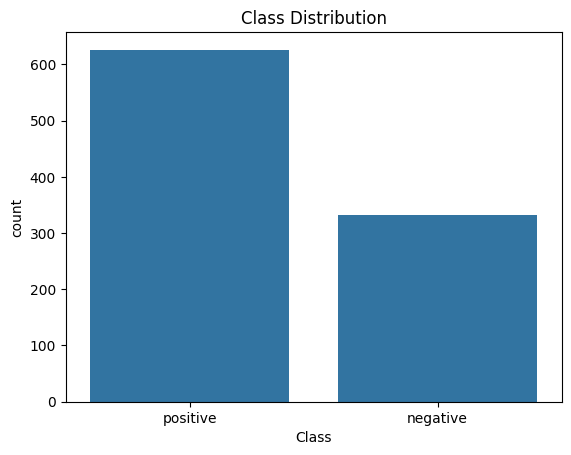

In [ ]:
sns.countplot(x='Class', data=df)
plt.title('Class Distribution') #simple plot to show the count of the testing class
plt.show()

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
#training data using a 20% test size

In [ ]:
log_reg=LogisticRegression(random_state=42)
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1],
    'solver': ['liblinear', 'lbfgs']#liblinear is better for small dataset
                                    #lbfgs is better for large dataset
}
grid_search_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='accuracy')#testing the best hyperparamter by using the grid search
grid_search_lr.fit(X_train, y_train)
best_params_lr = grid_search_lr.best_params_
best_estimator_lr = grid_search_lr.best_estimator_
best_acc_lr = grid_search_lr.best_score_
print("best acc:",best_acc_lr)
print("Best parameter:", best_params_lr)

best acc: 0.9856633562515915
Best parameter: {'C': 1, 'solver': 'liblinear'}


In [ ]:
per=Perceptron(random_state=42)
param_grid_p = {
    'alpha': [0.001, 0.01, 0.1,1],#how much the model is penalized for being too complex
    'penalty': ['l2', 'l1', None]}
    #l1 may make some features that have a samll importance = 0
    #l2 Keeps all features
grid_search_p = GridSearchCV(per, param_grid_p, cv=5, scoring='accuracy')
grid_search_p.fit(X_train, y_train)
best_params_p = grid_search_p.best_params_
best_estimator_p = grid_search_p.best_estimator_
best_acc_p = grid_search_p.best_score_
print("best acc:",best_acc_p)#calc the best accuracy
print("Best parameter: ",best_params_p)#find the best hyperparameter


best acc: 0.9804345980816569
Best parameter:  {'alpha': 0.001, 'penalty': 'l1'}


In [ ]:
Dec_tree=DecisionTreeClassifier(random_state=42)
param_grid_dt = {'criterion': ['gini', 'entropy'],
#gini measures the probability that a randomly chosen element from the set would be incorrectly labeled
# entropy Entropy comes from Information Theory and measures disorder in the data.
    'max_depth': [None, 5, 10, 15, 20],#how many questions the tree can ask from the root to the final leaf
                 #every question is a step deeper
    'min_samples_split': [2, 5, 10]}#its how much nodes is into split
grid_search_dt = GridSearchCV(Dec_tree, param_grid_dt, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)
best_params_dt = grid_search_dt.best_params_
best_estimator_dt = grid_search_dt.best_estimator_#the best estimator returns the trained model that achieved the best cross-validation performance
best_acc_dt = grid_search_dt.best_score_
print("best acc:",best_acc_dt)
print("Best parameter:", best_params_dt)




best acc: 0.9569391392920805
Best parameter: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}


In [ ]:
SVM= SVC(random_state=42)
param_grid_svm={'C': [0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf'],
    }
grid_search_svm = GridSearchCV(SVM, param_grid_svm, cv=5, scoring='accuracy')
grid_search_svm.fit(X_train, y_train)
best_params_svm = grid_search_svm.best_params_
best_estimator_svm = grid_search_svm.best_estimator_
best_acc_svm = grid_search_svm.best_score_
print("best acc:",best_acc_svm)
print("Best parameter:", best_params_svm)


best acc: 0.9869705457940754
Best parameter: {'C': 1, 'kernel': 'rbf'}


In [ ]:
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [5, 10, 20],#the nuber of trees is going to make a desicion
    # why 20? because it takes 20 diff trees decsions so if there is overfitting
    #  their individual mistakes cancel each other out
    'max_depth': [None, 10, 20],
    'criterion': ['gini', 'entropy']
}
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
best_params_rf = grid_search_rf.best_params_
best_estimator_rf = grid_search_rf.best_estimator_
best_acc_rf = grid_search_rf.best_score_
print("best acc:",best_acc_rf)
print("Best parameter:", best_params_rf)

best acc: 0.9869365928189457
Best parameter: {'criterion': 'entropy', 'max_depth': None, 'n_estimators': 20}


In [ ]:
dictionary={
    'Logistic Regression':(best_acc_lr),
    "Perceptron":(best_acc_p),
    "Decision Tree":(best_acc_dt),# creating a dictionary holding all algo so we could find the best of them
    "SVM":(best_acc_svm),
    "Random Forest":(best_acc_rf)
}



In [ ]:
best_model_name = max(dictionary, key=dictionary.get)#the key represtnted the values not the keys , max returns the hieghtest value
best_score = dictionary[best_model_name]

print(f"The best model is {best_model_name} with an accuracy of: {best_score:.4f}")

The best model is SVM with an accuracy of: 0.9870


In [ ]:
best_estimator_svm.fit(X_train, y_train)#heree we used the best model of the svm
y_pred = best_estimator_svm.predict(X_test)# we made a prediction
print(classification_report(y_test, y_pred))
#the precision tell us When the model says 'X Wins', how often is it actually right?
#Recall Of all the actual 'X Wins' in the test set, how many did the model find?
#F1-Score The  mean of the two. If this is high , your model has mastered the game's logic.


              precision    recall  f1-score   support

           0       1.00      0.94      0.97        67
           1       0.97      1.00      0.98       125

    accuracy                           0.98       192
   macro avg       0.98      0.97      0.98       192
weighted avg       0.98      0.98      0.98       192



In [ ]:
import joblib
joblib.dump(SVM, "tic.pkl")# a test data model to try the model on


['tic.pkl']

In [ ]:
from sklearn.inspection import permutation_importance

# The 'estimator' parameter should be the best fitted model, not its score.
# 'best_estimator_svm' holds the fitted SVM model with the best parameters., we used it because the fitting expects a model not just a value " number"
result = permutation_importance( #this method representes the Feature Importance by the estimator
    best_estimator_svm,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)
result.importances_mean


array([0.19791667, 0.12604167, 0.18958333, 0.1078125 , 0.246875  ,
       0.1140625 , 0.16354167, 0.1125    , 0.19010417])

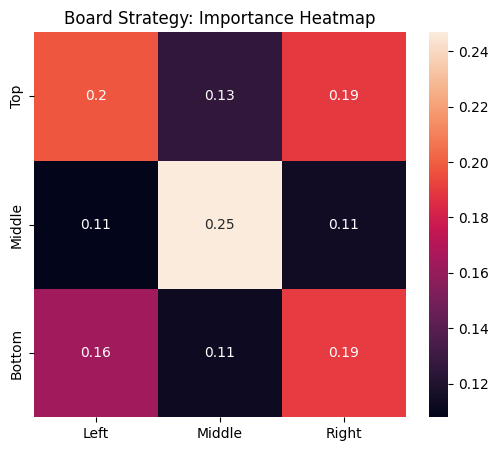

In [ ]:
importance_grid = result.importances_mean.reshape(3, 3)
plt.figure(figsize=(6, 5))
sns.heatmap(importance_grid, annot=True,
            xticklabels=['Left', 'Middle', 'Right'],
            yticklabels=['Top', 'Middle', 'Bottom'])
plt.title("Board Strategy: Importance Heatmap")
plt.show()

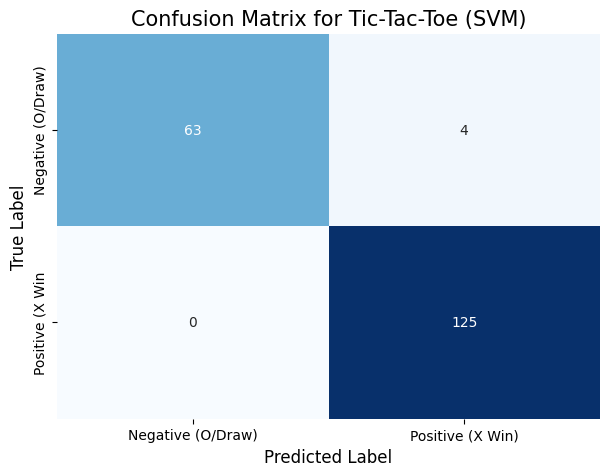

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = best_estimator_svm.predict(X_test)4
cm = confusion_matrix(y_test, y_pred)#comparing between the predictionn and the real target values
 #simple explaination , the True Positives (125) tells that the model took the right prediction (X will win ) 125 time
# the True Negatives(63)tells that the model took the right predicition (O/Draw) 63 times
#the False Positives (4)tells that the model took the wrong predicition that (X)will win 4 times
#the False Negatives is ZERO times predict that (x) loses and its acually wins
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative (O/Draw)', 'Positive (X Win)'],10
            yticklabels=['Negative (O/Draw)','Positive (X Win'])

plt.title(f'Confusion Matrix for Tic-Tac-Toe (SVM)', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],#its the number of the correct answers that taken to correct errors
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]#The percentage of data each expert is allowed to see to keep their perspective unique.swsda
}
grid_search_gb = GridSearchCV(
    gb,
    param_grid_gb,
    cv=5,
    scoring='accuracy',
)
grid_search_gb.fit(X_train, y_train)
print("Gradient Boosting  Accuracy:", grid_search_gb.best_score_)


Gradient Boosting  Accuracy: 0.9908751379339614


In [ ]:
dictionary_new={
    'Logistic Regression':(best_acc_lr),
    "Perceptron":(best_acc_p),
    "Decision Tree":(best_acc_dt),# creating a dictionary holding all algo so we could find the best of them
    "SVM":(best_acc_svm),
    "Random Forest":(best_acc_rf),
    "Gradient Boosting":(grid_search_gb.best_score_)

}

In [ ]:
best_model_name = max(dictionary_new, key=dictionary_new.get)
best_score = dictionary_new[best_model_name]
print(f"The best model is {best_model_name} with an accuracy of: {best_score:.4f}")

The best model is Gradient Boosting with an accuracy of: 0.9909
